In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
print(df.info())

print(df.describe())

print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None
       CustomerID         Age  Annual Income (k$)  Spending Score (1-100)
count  200.000000  200.000000          200.000000              200.000000
mean   100.500000   38.850000           60.560000               50.200000
std     57.879185   13.969007           26.264721               25.823522
min      1.000000   18.000000           15.000000                1.000000
25%     50.750000   28.750000           41.500000               34.750000
50%    100.500000   36.000000    

In [4]:
df = df.drop("CustomerID", axis=1)

In [5]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

In [6]:
df.head()

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [7]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [8]:
inertia = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_data)

    inertia.append(model.inertia_)

C:\Users\22053\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\22053\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\22053\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\22053\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

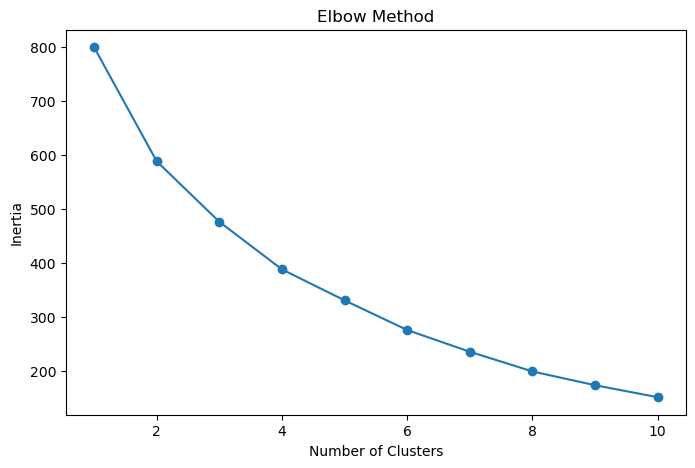

In [9]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), inertia, marker='o')

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()

In [10]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

kmeans.fit(scaled_data)

labels = kmeans.labels_

df["Cluster"] = labels

C:\Users\22053\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


In [11]:
print("Inertia :", kmeans.inertia_)

print("Silhouette Score :", silhouette_score(scaled_data, labels))

Inertia : 331.3098837641086
Silhouette Score : 0.3040600988258827


In [12]:
centers = scaler.inverse_transform(kmeans.cluster_centers_)

centers = pd.DataFrame(
    centers,
    columns=df.columns[:-1]
)

print(centers)

         Gender        Age  Annual Income (k$)  Spending Score (1-100)
0  4.615385e-01  32.692308           86.538462               82.128205
1  4.482759e-01  36.482759           89.517241               18.000000
2 -5.551115e-17  49.813953           49.232558               40.069767
3  4.074074e-01  24.907407           39.722222               61.203704
4  1.000000e+00  55.714286           53.685714               36.771429


In [13]:
summary = df.groupby("Cluster").mean()

print(summary)

           Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                 
0        0.461538  32.692308           86.538462               82.128205
1        0.448276  36.482759           89.517241               18.000000
2        0.000000  49.813953           49.232558               40.069767
3        0.407407  24.907407           39.722222               61.203704
4        1.000000  55.714286           53.685714               36.771429
